#### 1. Proximity based topography compared to true river routing
We inferr a proximity-based graph by connecting gauges that are geographically close and compare its adjacency to the known river-routing graph using qualitative inspection of false positives/negatives.”

In [1]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium


DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

id_conversion = pd.read_csv('site_id_naming_reference.csv', dtype={'site_id': str})

metadata = metadata.merge(id_conversion[['site_id', 'site_rename']], on='site_id', how='left')
metadata['site_rename'] = metadata['site_rename'].str.replace(' ', '', regex=False)

metadata[['site_id', 'site_name', 'site_rename']]

# import torch
# river_network.data.node_avgprecip = torch.tensor(mean_precipitation)

graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"), # NOTE site 26 is th outlet of the Pepcaton reservoir so all these other sites lead to the reservoir
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins
river_network = pp.Graph.from_edge_list(graph_edges_all).to_undirected()

Spatial proximity edge inference vs. true river routing
  |E_true|=30, |E_inferred|=51
  True Positives=17, False Positives=34, False Negatives=13


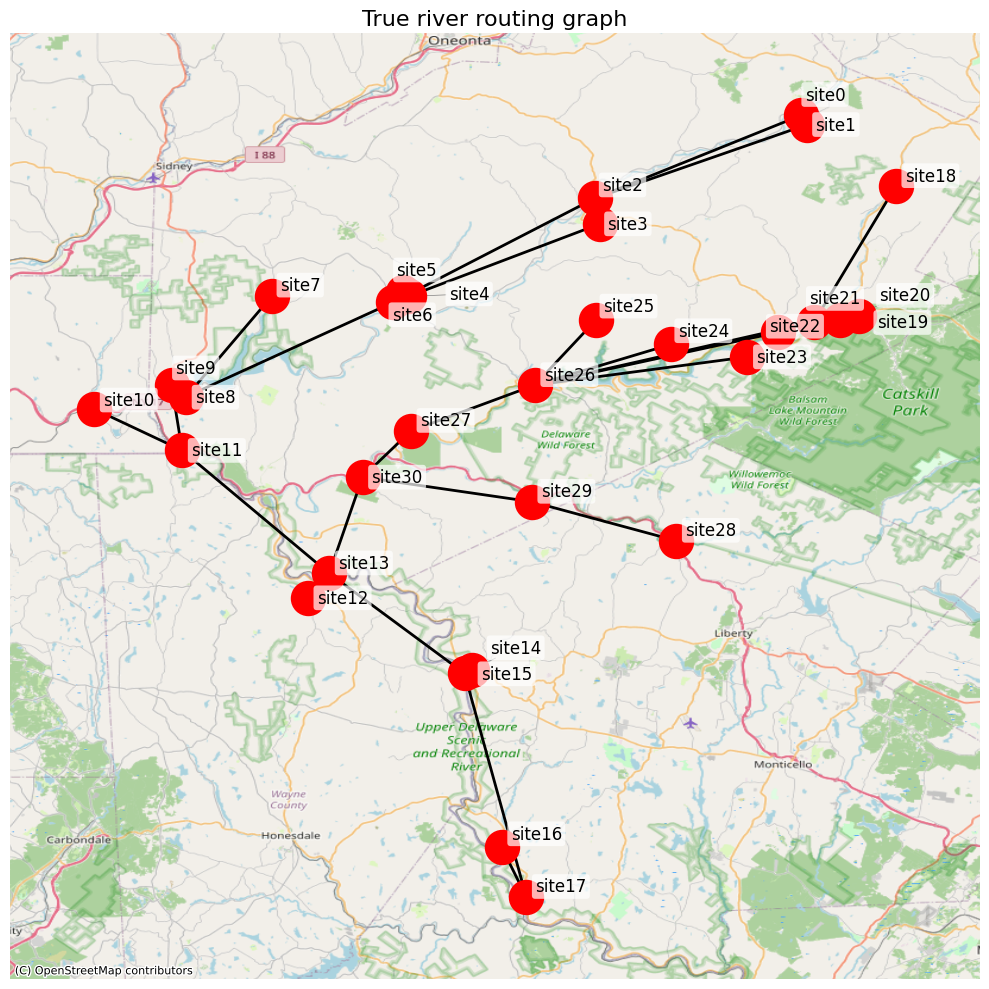

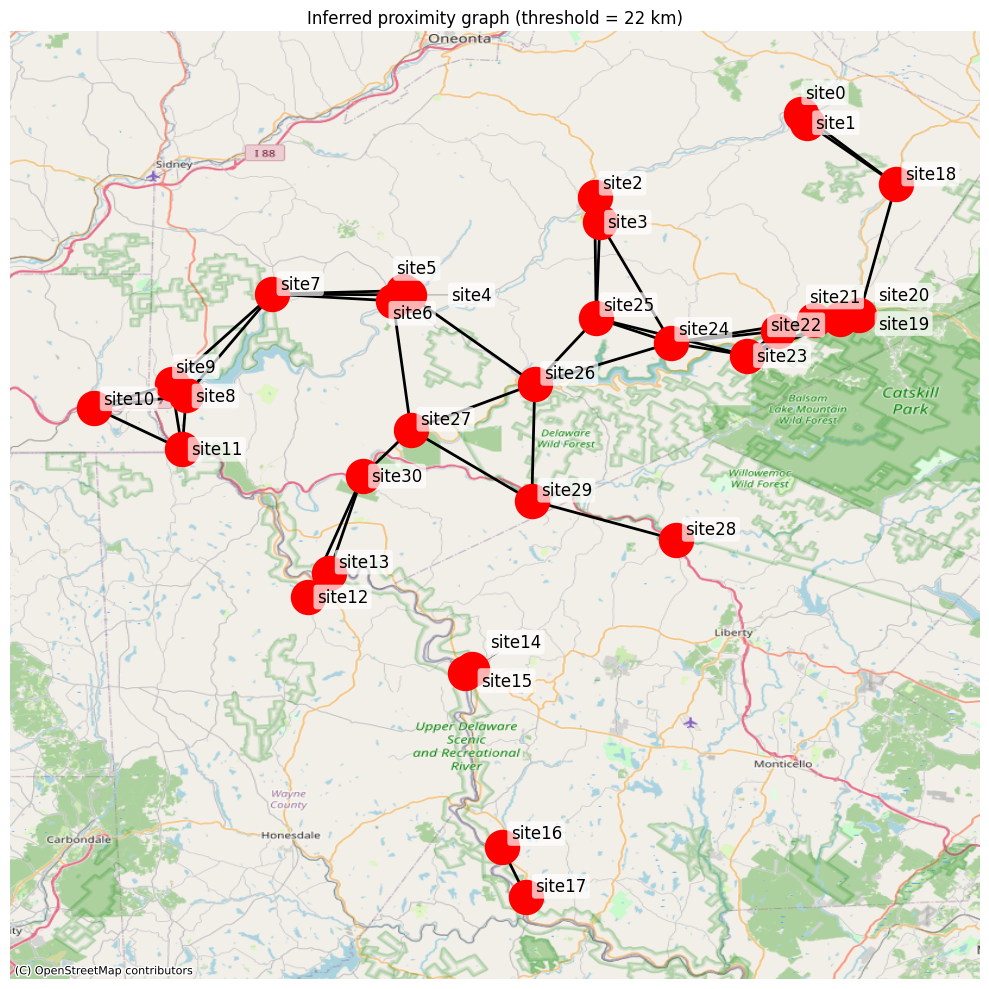

TP edges: 17, FN edges: 13, FP edges: 34


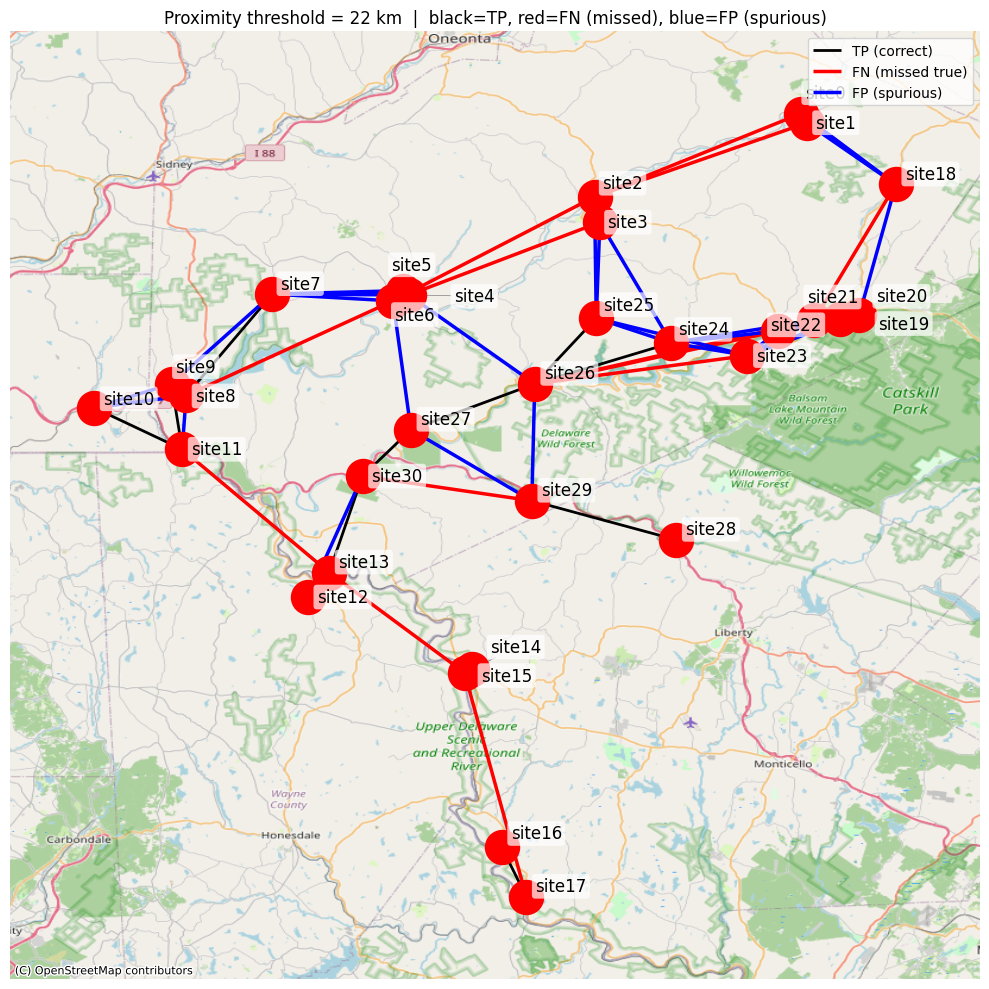

: 

In [ ]:
from adjustText import adjust_text 

# --- Proximity-based edge inference (EPSG:3857, meters) ---
gdf = gpd.GeoDataFrame(
    metadata,
    geometry=gpd.points_from_xy(metadata["longitude"], metadata["latitude"]),
    crs="EPSG:4326",
).to_crs("EPSG:3857")  # project to meters

coords = {row["site_rename"]: (row.geometry.x, row.geometry.y) for _, row in gdf.iterrows()}
nodes = list(river_network.mapping.node_ids)  # string IDs, consistent with rest of notebook

E_true = {tuple(sorted((u, v))) for (u, v) in river_network.edges}

# --- Infer edges: connect any pair of gauges within 22 km ---
dist_threshold_km = 22
dist_threshold_m  = dist_threshold_km * 1_000
E_inf = set()
for i in range(len(nodes)):
    for j in range(i + 1, len(nodes)):
        u, v = nodes[i], nodes[j]
        xu, yu = coords[u]
        xv, yv = coords[v]
        if np.sqrt((xu - xv)**2 + (yu - yv)**2) <= dist_threshold_m:
            E_inf.add(tuple(sorted((u, v))))

# --- Evaluation metrics ---
tp = len(E_true & E_inf)
fp = len(E_inf  - E_true)
fn = len(E_true - E_inf)

print("Spatial proximity edge inference vs. true river routing")
print(f"  |E_true|={len(E_true)}, |E_inferred|={len(E_inf)}")
print(f"  True Positives={tp}, False Positives={fp}, False Negatives={fn}")

# --- Plot 1: Inferred proximity graph (pathpyG) ---
river_network_inf = pp.Graph.from_edge_list(list(E_inf)).to_undirected()
pp.plot(river_network_inf, node_label=[x for x in river_network_inf.mapping.node_ids])

import networkx as nx

# Use actual geographic coordinates (EPSG:3857) as layout positions
pos = {node: coords[node] for node in nodes}

# --- Plot 2: True graph on geographic map ---
G_true = nx.Graph()
G_true.add_nodes_from(nodes)
G_true.add_edges_from(list(E_true))

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_nodes(G_true, pos=pos, node_size=600, node_color="red", ax=ax)
# nx.draw_networkx_labels(G_true, pos=pos, font_size=12, ax=ax)
nx.draw_networkx_edges(G_true, pos=pos, edgelist=list(E_true), edge_color="black", width=2.0, ax=ax)
texts = [ax.text(x, y, node, fontsize=12,   
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))  
    for node, (x, y) in pos.items()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title("True river routing graph", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.savefig("figures/true_graph_map.png", dpi=300)
plt.show()

# --- Plot 3: Inferred graph on geographic map ---
G_inf = nx.Graph()
G_inf.add_nodes_from(nodes)
G_inf.add_edges_from(list(E_inf))

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_nodes(G_inf, pos=pos, node_size=600, node_color="red", ax=ax)
# nx.draw_networkx_labels(G_inf, pos=pos, font_size=7, ax=ax)
nx.draw_networkx_edges(G_inf, pos=pos, edgelist=list(E_inf), edge_color="black", width=2.0, ax=ax)
texts = [ax.text(x, y, node, fontsize=12,   
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))  
    for node, (x, y) in pos.items()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title(f"Inferred proximity graph (threshold = {dist_threshold_km} km)")
ax.axis("off")
plt.tight_layout()
plt.savefig("figures/inferred_graph_map.png", dpi=300)
plt.show()

# --- Plot 4: TP / FN / FP comparison on geographic map ---
E_tp = E_true & E_inf   # correctly inferred
E_fn = E_true - E_inf   # missed true edges
E_fp = E_inf  - E_true  # spurious edges

print(f"TP edges: {len(E_tp)}, FN edges: {len(E_fn)}, FP edges: {len(E_fp)}")

G_all = nx.Graph()
G_all.add_nodes_from(nodes)
G_all.add_edges_from(list(E_true | E_inf))  # union so all nodes have positions

fig, ax = plt.subplots(figsize=(10, 10))
nx.draw_networkx_nodes(G_all, pos=pos, node_size=600, node_color="red", ax=ax)
# nx.draw_networkx_labels(G_all, pos=pos, font_size=7, ax=ax)
nx.draw_networkx_edges(G_all, pos=pos, edgelist=list(E_tp), edge_color="black", width=2.0, ax=ax, label="TP (correct)")
nx.draw_networkx_edges(G_all, pos=pos, edgelist=list(E_fn), edge_color="red",   width=2.5, ax=ax, label="FN (missed true)")
nx.draw_networkx_edges(G_all, pos=pos, edgelist=list(E_fp), edge_color="blue",  width=2.5, ax=ax, label="FP (spurious)")
texts = [ax.text(x, y, node, fontsize=12,   
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))  
    for node, (x, y) in pos.items()]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title(f"Proximity threshold = {dist_threshold_km} km  |  black=TP, red=FN (missed), blue=FP (spurious)")
ax.axis("off")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("figures/proximity_vs_true_comparison.png", dpi=300)
plt.show()
